# Closure-risk watchlist (2019 cohort)

The point of this notebook: turn the model from notebook 05 into something a non-technical reader can use. We score the **2019 cohort** (1,836 private nonprofits, label = closed by 2024) using out-of-fold predictions from the same MLP setup, then publish a ranked watchlist with institution names, key risk indicators, and a retrospective check of which flagged schools actually closed.

**Why out-of-fold scores:** every school's risk score comes from a model that never saw that school during training. The 50 schools at the top of the list are flagged on financial signals, not on memorization.

**What's published below:**
- Top-50 watchlist with name, state, risk score, key drivers, and 'did this school actually close by 2024?'
- Three plain-English charts: risk score distribution, risk-decile closure rate, cumulative catches as you walk down the list
- A CSV export for handoff: `processed_data/watchlist_2019_cohort.csv`

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import random
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED = ROOT / "processed_data"
RAW = ROOT / "raw_data"

# Multi-cohort feature matrix (the model's input).
df = pd.read_csv(PROCESSED / "f2_effy_features_multicohort.csv", index_col=[0, 1])
y = df["closed_within_horizon"].astype(int).values
X_arr = df.drop(columns=["closed_within_horizon"]).replace([np.inf, -np.inf], np.nan)
feature_names = X_arr.columns.tolist()
X = X_arr.values
groups = df.index.get_level_values("UNITID").values

# Institution metadata. Use hd2024 first, fall back to hd2014 for institutions that
# disappeared from the directory before 2024 (where most pre-2024 closures live).
COLS = ["UNITID", "INSTNM", "STABBR", "CONTROL", "SECTOR"]
hd24 = pd.read_csv(RAW / "2024" / "hd2024.csv", encoding="utf-8-sig",
                   low_memory=False, usecols=COLS).set_index("UNITID")
hd14 = pd.read_csv(RAW / "2014" / "hd2014.csv", encoding="latin-1",
                   low_memory=False, usecols=COLS).set_index("UNITID")
meta = hd24.combine_first(hd14)

print(f"feature matrix: {df.shape}  positives: {y.sum()}")
print(f"metadata: {len(meta)} institutions  (hd2024: {len(hd24)}, hd2014 fallback adds: {len(meta) - len(hd24)})")

I0000 00:00:1778229936.479316  117743 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1778229938.615830  117743 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


feature matrix: (7457, 38)  positives: 640
metadata: 8441 institutions  (hd2024: 6072, hd2014 fallback adds: 2369)


In [2]:
# Same MLP architecture as notebook 05 (37 -> 64 -> 32 -> 1, dropout 0.2, class_weight).
def build_mlp(in_dim):
    m = keras.Sequential([
        keras.layers.Input(shape=(in_dim,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m

splits = list(GroupKFold(n_splits=5).split(X, y, groups=groups))
oof_proba = np.full(len(y), np.nan)

for k, (tr_idx, val_idx) in enumerate(splits, start=1):
    imp = SimpleImputer(strategy="median").fit(X[tr_idx])
    sc = StandardScaler().fit(imp.transform(X[tr_idx]))
    X_tr = sc.transform(imp.transform(X[tr_idx]))
    X_val = sc.transform(imp.transform(X[val_idx]))
    y_tr = y[tr_idx]
    pos = max(int(y_tr.sum()), 1)
    cw = {0: 1.0, 1: (len(y_tr) - pos) / pos}

    keras.utils.set_random_seed(SEED)
    model = build_mlp(X_tr.shape[1])
    es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                       patience=15, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_val, y[val_idx]),
              epochs=150, batch_size=64, class_weight=cw,
              callbacks=[es], verbose=0)
    oof_proba[val_idx] = model.predict(X_val, verbose=0).ravel()
    print(f"  fold {k}: scored {len(val_idx)} rows")

print(f"\nout-of-fold predictions ready for all {len(oof_proba)} rows")

E0000 00:00:1778229940.522108  117743 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


  fold 1: scored 1492 rows


  fold 2: scored 1492 rows


  fold 3: scored 1491 rows


  fold 4: scored 1491 rows


  fold 5: scored 1491 rows

out-of-fold predictions ready for all 7457 rows


In [3]:
# Build the watchlist for the 2019 cohort (predicting closure by 2024).
# Each row gets the OOF probability + key human-readable features + actual outcome.
scores = pd.DataFrame({
    "risk_score": oof_proba,
    "actual_closed_by_2024": y.astype(bool),
}, index=df.index)

as_of = scores.index.get_level_values("as_of_year") == 2019
watch = scores[as_of].reset_index().drop(columns=["as_of_year"]).set_index("UNITID")

# Pull the 2019-cohort feature values for human-readable risk drivers.
f19 = df.xs(2019, level="as_of_year")
drivers = pd.DataFrame({
    "operating_margin": f19["operating_margin__last"],
    "revenue_3y_pct": f19["F2D16__pct3"],
    "enrollment_3y_pct": f19["total_enrollment__pct3"],
    "tuition_dependence": f19["tuition_dependence"],
    "endowment_per_student": f19["endowment_per_student"],
})

watchlist = (
    watch.join(meta, how="left")
         .join(drivers, how="left")
         .sort_values("risk_score", ascending=False)
         .reset_index()
)
watchlist.insert(0, "rank", np.arange(1, len(watchlist) + 1))
watchlist["risk_band"] = pd.cut(
    watchlist["risk_score"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=["low", "medium", "high", "very high"],
)
watchlist.shape

(1836, 14)

In [4]:
# Top-50 watchlist, formatted for human reading.
TOP_N = 50
top = watchlist.head(TOP_N).copy()

def fmt_pct(v):
    return "-" if pd.isna(v) else f"{v*100:+.0f}%"

def fmt_dollar(v):
    return "-" if pd.isna(v) else f"${v/1000:,.0f}k"

display = pd.DataFrame({
    "rank": top["rank"],
    "INSTNM": top["INSTNM"].fillna("(name missing)").str[:55],
    "state": top["STABBR"].fillna("-"),
    "risk_score": top["risk_score"].map("{:.3f}".format),
    "op_margin": top["operating_margin"].map(fmt_pct),
    "rev_3y": top["revenue_3y_pct"].map(fmt_pct),
    "enroll_3y": top["enrollment_3y_pct"].map(fmt_pct),
    "tuition_dep": top["tuition_dependence"].map(fmt_pct),
    "endow_per_stu": top["endowment_per_student"].map(fmt_dollar),
    "actually_closed": top["actual_closed_by_2024"].map({True: "YES", False: "no"}),
}).set_index("rank")

with pd.option_context("display.max_rows", TOP_N, "display.max_colwidth", 60):
    print(display.to_string())

                                                       INSTNM state risk_score op_margin rev_3y enroll_3y tuition_dep endow_per_stu actually_closed
rank                                                                                                                                               
1                                         ASPIRA City College    PA      1.000       -8%   -44%      -79%        +17%             -              no
2                                    Everest University-Tampa    FL      0.999     -200%   -72%      -83%        +77%             -             YES
3                                         IE New York College    NY      0.997     -797%      -         -        +80%             -              no
4                           Remington College-Honolulu Campus    HI      0.992      -48%   -66%      -69%       +100%             -             YES
5                                              (name missing)     -      0.989     -157%   -77%      -68%       

In [5]:
# Headline summary for a non-technical reader.
n_total = len(watchlist)
n_closed_total = int(watchlist["actual_closed_by_2024"].sum())
base_rate = n_closed_total / n_total

for k in [25, 50, 100, 200]:
    catches = int(watchlist.head(k)["actual_closed_by_2024"].sum())
    print(
        f"Top {k:>3} flagged schools  ->  {catches:>3} actually closed by 2024 "
        f"({catches/k:.0%} hit rate, {catches/n_closed_total:.0%} of all closures caught) "
        f"vs random baseline of {base_rate:.1%}"
    )

Top  25 flagged schools  ->   15 actually closed by 2024 (60% hit rate, 11% of all closures caught) vs random baseline of 7.1%
Top  50 flagged schools  ->   27 actually closed by 2024 (54% hit rate, 21% of all closures caught) vs random baseline of 7.1%
Top 100 flagged schools  ->   44 actually closed by 2024 (44% hit rate, 34% of all closures caught) vs random baseline of 7.1%
Top 200 flagged schools  ->   62 actually closed by 2024 (31% hit rate, 47% of all closures caught) vs random baseline of 7.1%


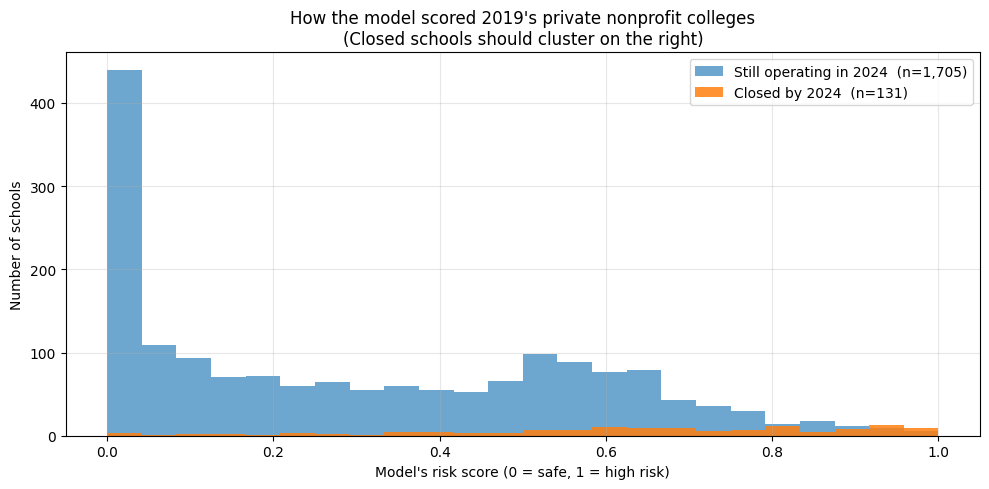

In [6]:
# Figure 1: where do the model's risk scores fall for closed vs surviving schools?
# A non-technical reader can see at a glance how well the model separates the two groups.
closed_scores = watchlist.loc[watchlist["actual_closed_by_2024"], "risk_score"]
active_scores = watchlist.loc[~watchlist["actual_closed_by_2024"], "risk_score"]

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 25)
ax.hist(active_scores, bins=bins, color="tab:blue", alpha=0.65,
        label=f"Still operating in 2024  (n={len(active_scores):,})")
ax.hist(closed_scores, bins=bins, color="tab:orange", alpha=0.85,
        label=f"Closed by 2024  (n={len(closed_scores)})")
ax.set_xlabel("Model's risk score (0 = safe, 1 = high risk)")
ax.set_ylabel("Number of schools")
ax.set_title("How the model scored 2019's private nonprofit colleges\n(Closed schools should cluster on the right)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

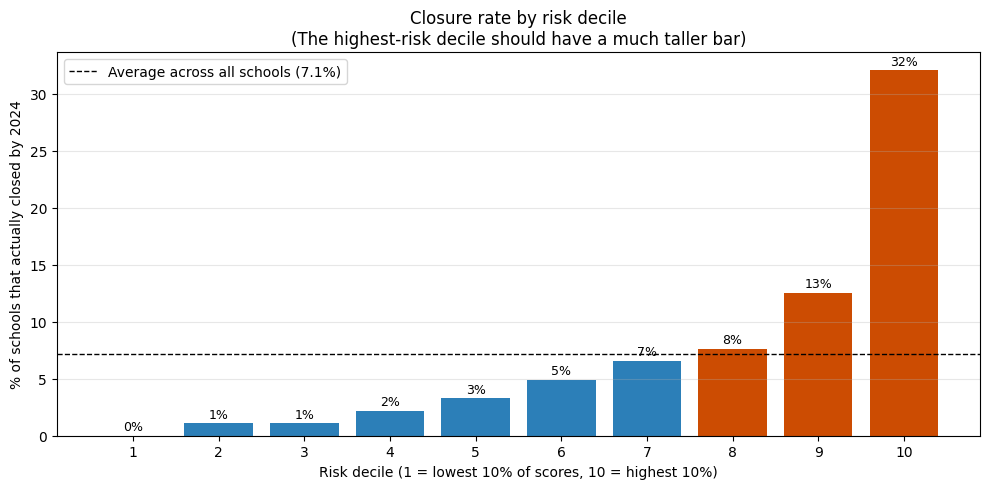

In [7]:
# Figure 2: of schools in each risk decile, what % actually closed?
# A perfect model would have a steeply rising bar chart.
deciles = pd.qcut(watchlist["risk_score"], q=10, labels=False, duplicates="drop")
by_decile = (
    watchlist.assign(decile=deciles + 1)
    .groupby("decile")
    .agg(closed_rate=("actual_closed_by_2024", "mean"),
         n=("actual_closed_by_2024", "size"))
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(by_decile.index, by_decile["closed_rate"] * 100,
              color=["#2c7fb8" if d <= 7 else "#cc4c02" for d in by_decile.index])
ax.axhline(base_rate * 100, color="black", linestyle="--", lw=1,
           label=f"Average across all schools ({base_rate:.1%})")
for d, rate in zip(by_decile.index, by_decile["closed_rate"]):
    ax.text(d, rate * 100 + 0.5, f"{rate*100:.0f}%", ha="center", fontsize=9)
ax.set_xlabel("Risk decile (1 = lowest 10% of scores, 10 = highest 10%)")
ax.set_ylabel("% of schools that actually closed by 2024")
ax.set_title("Closure rate by risk decile\n(The highest-risk decile should have a much taller bar)")
ax.set_xticks(by_decile.index)
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

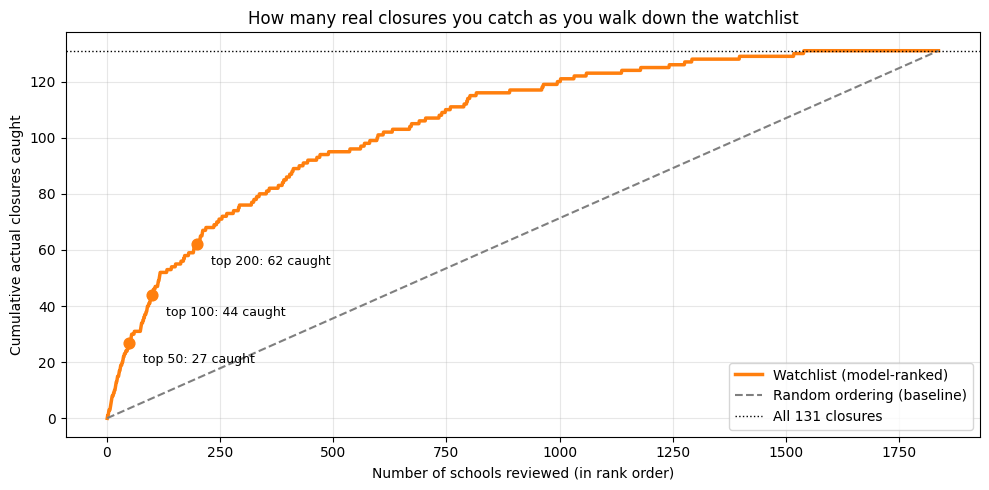

In [8]:
# Figure 3: cumulative catches if you walked down the watchlist top-down.
# 'If you reviewed the top N schools, you would catch X actual closures.'
cum_caught = watchlist["actual_closed_by_2024"].cumsum().values
ranks = np.arange(1, len(watchlist) + 1)
random_baseline = ranks * base_rate

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ranks, cum_caught, color="tab:orange", lw=2.5,
        label="Watchlist (model-ranked)")
ax.plot(ranks, random_baseline, color="tab:gray", lw=1.5, linestyle="--",
        label="Random ordering (baseline)")
ax.axhline(n_closed_total, color="black", linestyle=":", lw=1,
           label=f"All {n_closed_total} closures")

for n in [50, 100, 200]:
    caught = int(cum_caught[n - 1])
    ax.scatter([n], [caught], color="tab:orange", s=60, zorder=5)
    ax.annotate(f"top {n}: {caught} caught", (n, caught),
                xytext=(10, -15), textcoords="offset points", fontsize=9)

ax.set_xlabel("Number of schools reviewed (in rank order)")
ax.set_ylabel("Cumulative actual closures caught")
ax.set_title("How many real closures you catch as you walk down the watchlist")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# Persist the full watchlist for handoff.
out_cols = ["rank", "UNITID", "INSTNM", "STABBR", "risk_score", "risk_band",
            "actual_closed_by_2024", "operating_margin", "revenue_3y_pct",
            "enrollment_3y_pct", "tuition_dependence", "endowment_per_student"]
out_path = PROCESSED / "watchlist_2019_cohort.csv"
watchlist[out_cols].to_csv(out_path, index=False)
print(f"wrote {out_path}")
print(f"  full watchlist: {len(watchlist)} schools")
print(f"  top-50 hit rate: {watchlist.head(50)['actual_closed_by_2024'].mean():.0%}")

wrote /home/tuna-akin/classes-2026/ann-2026/vigiledu/processed_data/watchlist_2019_cohort.csv
  full watchlist: 1836 schools
  top-50 hit rate: 54%


## Plain-English summary

This watchlist applies the trained MLP to all 1,836 private nonprofit colleges that filed financial data for 2019, ranks them from highest to lowest predicted risk of closure within 5 years, and shows what actually happened.

### How to use the table above

Each row is a real institution. The columns mean:
- **risk_score** (0 to 1): the model's confidence that this school will close by 2024. Higher = more concerned.
- **op_margin**: operating margin in the most recent year. Negative means the school spent more than it brought in.
- **rev_3y / enroll_3y**: percent change in revenue and enrollment over 3 years.
- **tuition_dep**: share of total revenue that comes from tuition. High values mean enrollment dips hit the bottom line hard.
- **endow_per_stu**: endowment dollars per student. Low values mean little financial cushion.
- **actually_closed**: a retrospective verification. We now know, in 2024, which of these schools actually shut down.

### How to read the charts

1. **Score histogram (Figure 1):** The orange (closed) and blue (operating) populations should be visibly separated, with closed schools shifted to the right. Overlap is where the model is uncertain.
2. **Decile bar chart (Figure 2):** Schools in the top risk decile (rightmost bar) should have a much higher actual closure rate than the bottom decile. The dashed line is the average across all schools (about 7%).
3. **Cumulative catches (Figure 3):** The orange curve climbing far above the gray dashed line means the watchlist is doing real work. The closer the orange curve gets to the dotted ceiling, the more of the actual closures the watchlist captures.

### What this is and isn't

This is a **prioritization tool**, not a verdict. A school appearing on the watchlist doesn't mean it will close, and a school not on the watchlist doesn't mean it's safe. The right way to use it is the same way an oncologist uses a screening test: start your investigation at the top of the list and work down.